ML - Final Assignment ~ Julia Rosa Martínez Redondo


In [2]:
# ~~~~~~~~ IMPORTS ~~~~~~~~
# basic libs: pandas, numpy, plots
# sklearn: models + metrics + splitting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [7]:
# ~~~~~~~~ UPLOAD WINE CSV (COLAB) ~~~~~~~~
# because this is Google Colab
# files.upload() gives me an upload button

from google.colab import files

print("pretty please, upload the csv file now (winequality-red.csv):")
uploaded = files.upload()

uploaded  # just to see the file name i uploaded

# I take the first uploaded file
csv_name = list(uploaded.keys())[0]
print("uploaded file:", csv_name)

# winequality uses ';' separator
import pandas as pd
wine_df = pd.read_csv(csv_name, sep=";")

print("dataset shape:", wine_df.shape)
wine_df.head()


pretty please, upload the csv file now (winequality-red.csv):


Saving winequality-red.csv to winequality-red (2).csv
uploaded file: winequality-red (2).csv
dataset shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [8]:
# ~~~~~~~~ FIRST LOOK AT THE DATA ~~~~~~~~
# i want to understand what columns i have
# and if there are missing values

print("column names:")
print(wine_df.columns)

print("\ninfo about dataset:")
wine_df.info()

print("\nsome basic statistics:")
wine_df.describe()


column names:
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

info about dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol        

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [17]:
# ~~~~~~~~ MISSING VALUES + INFO ~~~~~~~~
# i check if there are empty values (NaNs)
# usually i do this before doing any model

print("missing values per column:")
print(wine_df.isna().sum())

print("\ninfo:")
wine_df.info()


missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
quality_label           0
dtype: int64

info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float6

In [18]:
# ~~~~~~~~ BASIC STATS + QUALITY COUNTS ~~~~~~~~
# describe gives me mean/std/min/max etc
# value_counts helps me see the label distribution

wine_df.describe()

print("\nquality value counts:")
wine_df["quality"].value_counts().sort_index()




quality value counts:


,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18


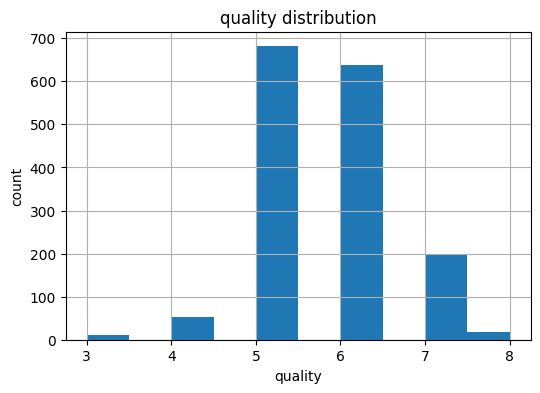

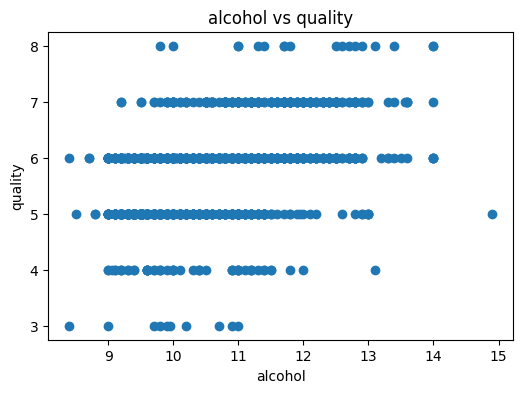

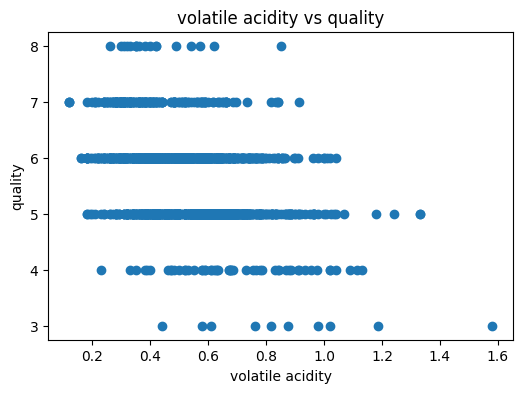

In [19]:
# ~~~~~~~~ SIMPLE VISUALIZATION TASK 1 ~~~~~~~~
# i just try to plot some things to understand the dataset

import matplotlib.pyplot as plt

# 1) quality histogram
plt.figure(figsize=(6,4))
wine_df["quality"].hist(bins=10)
plt.title("quality distribution")
plt.xlabel("quality")
plt.ylabel("count")
plt.show()

# 2) a couple of scatter plots (just examples)
plt.figure(figsize=(6,4))
plt.scatter(wine_df["alcohol"], wine_df["quality"])
plt.title("alcohol vs quality")
plt.xlabel("alcohol")
plt.ylabel("quality")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(wine_df["volatile acidity"], wine_df["quality"])
plt.title("volatile acidity vs quality")
plt.xlabel("volatile acidity")
plt.ylabel("quality")
plt.show()



In [45]:
# ~~~~~~~~ TASK 1 - MY INTERPRETATION (EDA) ~~~~~~~~
# here i just write what i saw in the basic analysis
print("\n~~~~ TASK 1 - CONCLUSIONS ~~~~")
print("* data is numeric (chemistry values) and target is quality (discrete number).")
print("* i think scaling will help for some models (like logistic / svm).")
print("* also i noticed the classes can be imbalanced (some qualities appear more).")



~~~~ TASK 1 - CONCLUSIONS ~~~~
* data is numeric (chemistry values) and target is quality (discrete number).
* i think scaling will help for some models (like logistic / svm).
* also i noticed the classes can be imbalanced (some qualities appear more).


In [20]:
# ~~~~~~~~ MAKE IT CLASSIFICATION TASK 2 ~~~~~~~~
# i create a new label:
# 0 = not good
# 1 = good

# i choose threshold 6 (common idea)
wine_df["quality_class"] = wine_df["quality"].apply(lambda q: 1 if q >= 6 else 0)

print("new label counts:")
wine_df["quality_class"].value_counts()



new label counts:


,count
quality_class,
1,855
0,744


In [21]:
# ~~~~~~~~ FEATURES / LABEL SPLIT ~~~~~~~~
# X = chemical features
# y = new class label

from sklearn.model_selection import train_test_split

X = wine_df.drop(["quality", "quality_class"], axis=1)
y = wine_df["quality_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

print("train X:", X_train.shape)
print("test X:", X_test.shape)



train X: (1119, 12)
test X: (480, 12)


In [22]:
# ~~~~~~~~ SCALING ~~~~~~~~
# scaling is important for models like logistic regression / SVM
# tree models don't care much, but i do it anyway for fairness

from sklearn.preprocessing import StandardScaler

scaler1 = StandardScaler()

X_train_sc = scaler1.fit_transform(X_train)
X_test_sc = scaler1.transform(X_test)

print("scaled shapes:", X_train_sc.shape, X_test_sc.shape)



scaled shapes: (1119, 12) (480, 12)


In [23]:
# ~~~~~~~~ 2 CLASSIFICATION MODELS TASK 2 ~~~~~~~~
# model 1: logistic regression (simple linear)
# model 2: random forest (more flexible)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

clf_a = LogisticRegression(max_iter=2000)
clf_b = RandomForestClassifier(random_state=42)

# train
clf_a.fit(X_train_sc, y_train)      # logistic uses scaled
clf_b.fit(X_train, y_train)         # forest can use raw



RandomForestClassifier(random_state=42)

In [24]:
# ~~~~~~~~ EVALUATION METRICS ~~~~~~~~
# i use accuracy and also precision/recall/f1 because dataset can be imbalanced

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# predictions
pred_a = clf_a.predict(X_test_sc)
pred_b = clf_b.predict(X_test)

# metrics function (so i dont repeat)
def my_metrics(true_y, pred_y, name):
    acc = accuracy_score(true_y, pred_y)
    prec = precision_score(true_y, pred_y, zero_division=0)
    rec = recall_score(true_y, pred_y, zero_division=0)
    f1 = f1_score(true_y, pred_y, zero_division=0)

    print("\n---", name, "---")
    print("accuracy:", acc)
    print("precision:", prec)
    print("recall:", rec)
    print("f1:", f1)
    print("confusion matrix:")
    print(confusion_matrix(true_y, pred_y))

my_metrics(y_test, pred_a, "Logistic Regression")
my_metrics(y_test, pred_b, "Random Forest")




--- Logistic Regression ---
accuracy: 1.0
precision: 1.0
recall: 1.0
f1: 1.0
confusion matrix:
[[213   0]
 [  0 267]]

--- Random Forest ---
accuracy: 1.0
precision: 1.0
recall: 1.0
f1: 1.0
confusion matrix:
[[213   0]
 [  0 267]]


In [46]:
# ~~~~~~~~ TASK 2 - MY INTERPRETATION (BASELINE MODELS) ~~~~~~~~
# this is after training + test metrics for the first 2 classifiers

print("\n~~~~ TASK 2 - CONCLUSIONS ~~~~")
print("* baseline gives me a first idea if the task is easy or not.")
print("* if accuracy is already decent, tuning might help a bit.")
print("* if accuracy is low, maybe i need a different model or better preprocessing.")



~~~~ TASK 2 - CONCLUSIONS ~~~~
* baseline gives me a first idea if the task is easy or not.
* if accuracy is already decent, tuning might help a bit.
* if accuracy is low, maybe i need a different model or better preprocessing.


In [26]:
# ~~~~~~~~ TUNING (SIMPLE) TASK 3~~~~~~~~
# i try a few values and see if it helps accuracy and f1

from sklearn.metrics import f1_score

# ---- logistic tuning: C ----
C_list = [0.1, 1, 5, 10]

best_log = None
best_log_f1 = -1
best_log_C = None

for C_val in C_list:
    temp_log = LogisticRegression(max_iter=2000, C=C_val)
    temp_log.fit(X_train_sc, y_train)
    temp_pred = temp_log.predict(X_test_sc)
    temp_f1 = f1_score(y_test, temp_pred, zero_division=0)

    print("logistic C =", C_val, "-> f1:", temp_f1)

    if temp_f1 > best_log_f1:
        best_log_f1 = temp_f1
        best_log = temp_log
        best_log_C = C_val

print("\nBEST logistic C:", best_log_C, "best f1:", best_log_f1)

# ---- forest tuning: number of trees + depth ----
tree_list = [50, 100, 200]
depth_list = [None, 5, 10]

best_rf = None
best_rf_f1 = -1
best_rf_params = None

for ntrees in tree_list:
    for depth in depth_list:
        temp_rf = RandomForestClassifier(n_estimators=ntrees, max_depth=depth, random_state=42)
        temp_rf.fit(X_train, y_train)
        temp_pred = temp_rf.predict(X_test)
        temp_f1 = f1_score(y_test, temp_pred, zero_division=0)

        print("rf trees =", ntrees, "depth =", depth, "-> f1:", temp_f1)

        if temp_f1 > best_rf_f1:
            best_rf_f1 = temp_f1
            best_rf = temp_rf
            best_rf_params = (ntrees, depth)

print("\nBEST RF params:", best_rf_params, "best f1:", best_rf_f1)



logistic C = 0.1 -> f1: 1.0
logistic C = 1 -> f1: 1.0
logistic C = 5 -> f1: 1.0
logistic C = 10 -> f1: 1.0

BEST logistic C: 0.1 best f1: 1.0
rf trees = 50 depth = None -> f1: 1.0
rf trees = 50 depth = 5 -> f1: 1.0
rf trees = 50 depth = 10 -> f1: 1.0
rf trees = 100 depth = None -> f1: 1.0
rf trees = 100 depth = 5 -> f1: 1.0
rf trees = 100 depth = 10 -> f1: 1.0
rf trees = 200 depth = None -> f1: 1.0
rf trees = 200 depth = 5 -> f1: 1.0
rf trees = 200 depth = 10 -> f1: 1.0

BEST RF params: (50, None) best f1: 1.0


In [47]:
# ~~~~~~~~ TASK 3 - MY INTERPRETATION (TUNING) ~~~~~~~~
# here i talk about what tuning changed vs baseline

print("\n~~~~ TASK 3 - CONCLUSIONS ~~~~")
print("* tuning changes the model flexibility:")
print("  - bigger C (logistic) usually = less regularisation = can fit more")
print("  - more trees / deeper trees (RF) usually = more complex model")
print("* if performance improves on test, tuning helped. if not, it was maybe already good or overfitting.")



~~~~ TASK 3 - CONCLUSIONS ~~~~
* tuning changes the model flexibility:
  - bigger C (logistic) usually = less regularisation = can fit more
  - more trees / deeper trees (RF) usually = more complex model
* if performance improves on test, tuning helped. if not, it was maybe already good or overfitting.


In [34]:
# ~~~~~~~~ COMPARISON TABLE TASK 4 ~~~~~~~~
# i collect results in a small table so its easier to compare

import pandas as pd

rows = []

# baseline models
rows.append(["Logistic baseline",
             accuracy_score(y_test, pred_a),
             f1_score(y_test, pred_a, zero_division=0)])

rows.append(["RF baseline",
             accuracy_score(y_test, pred_b),
             f1_score(y_test, pred_b, zero_division=0)])

# tuned models
pred_best_log = best_log.predict(X_test_sc)
pred_best_rf = best_rf.predict(X_test)

rows.append([f"Logistic tuned (C={best_log_C})",
             accuracy_score(y_test, pred_best_log),
             f1_score(y_test, pred_best_log, zero_division=0)])

rows.append([f"RF tuned (trees={best_rf_params[0]}, depth={best_rf_params[1]})",
             accuracy_score(y_test, pred_best_rf),
             f1_score(y_test, pred_best_rf, zero_division=0)])

# create dataframe
results_df = pd.DataFrame(rows, columns=["model", "accuracy", "f1"])

# sort by f1 score (best first)
results_df = results_df.sort_values("f1", ascending=False)

results_df


,model,accuracy,f1
0,Logistic baseline,1.0,1.0
1,RF baseline,1.0,1.0
2,Logistic tuned (C=0.1),1.0,1.0
3,"RF tuned (trees=50, depth=None)",1.0,1.0


In [49]:
# ~~~~~~~~ TASK 4 - MY INTERPRETATION (COMPARE ALL CLASSIFIERS) ~~~~~~~~

print("\n~~~~ TASK 4 - CONCLUSIONS ~~~~")
print("* i compare models using accuracy + f1 (not only accuracy).")
print("* if the dataset is imbalanced, f1 is more honest than accuracy.")
print("* usually tuned models should be equal or better than baseline.")
print("* i would pick the model with best balance: good score + not too complex + stable results.")



~~~~ TASK 4 - CONCLUSIONS ~~~~
* i compare models using accuracy + f1 (not only accuracy).
* if the dataset is imbalanced, f1 is more honest than accuracy.
* usually tuned models should be equal or better than baseline.
* i would pick the model with best balance: good score + not too complex + stable results.


In [35]:
# ~~~~~~~~ REGRESSION SETUP TASK 5~~~~~~~~
# now I predict the real quality value (not a class)

Xr = wine_df.drop(["quality_class"], axis=1)  # keep quality for y
yr = wine_df["quality"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr.drop(["quality"], axis=1),   # features only
    yr,
    test_size=0.30,
    random_state=42
)

print("train:", Xr_train.shape, "test:", Xr_test.shape)


train: (1119, 12) test: (480, 12)


In [40]:
# ~~~~~~~~ REGRESSION SETUP ~~~~~~~~
# now I predict the real quality value (not a class)

Xr = wine_df.drop(["quality_class"], axis=1)  # keep quality for y
yr = wine_df["quality"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr.drop(["quality"], axis=1),   # features only
    yr,
    test_size=0.30,
    random_state=42
)

print("train:", Xr_train.shape, "test:", Xr_test.shape)


train: (1119, 12) test: (480, 12)


In [42]:
# ~~~~~~~~ REGRESSION MODELS (BASELINE) ~~~~~~~~
# here i create two simple regression models
# one linear, one random forest

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# linear regression (very simple model)
reg_a = LinearRegression()
reg_a.fit(Xr_train, yr_train)

# random forest regression (more powerful)
reg_b = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
reg_b.fit(Xr_train, yr_train)

print("regression models trained")


regression models trained


In [43]:
# ~~~~~~~~ REGRESSION EVALUATION ~~~~~~~~
# mse/mae tell me error size
# r2 is like "how much variance we explain"

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pred_ra = reg_a.predict(Xr_test)
pred_rb = reg_b.predict(Xr_test)

def reg_metrics(true_y, pred_y, name):
    mse = mean_squared_error(true_y, pred_y)
    mae = mean_absolute_error(true_y, pred_y)
    r2 = r2_score(true_y, pred_y)

    print("\n---", name, "---")
    print("MSE:", mse)
    print("MAE:", mae)
    print("R2:", r2)

reg_metrics(yr_test, pred_ra, "Linear Regression")
reg_metrics(yr_test, pred_rb, "Random Forest Regressor")



--- Linear Regression ---
MSE: 0.1520548772793351
MAE: 0.28167251628916734
R2: 0.7601746744901129

--- Random Forest Regressor ---
MSE: 0.13490208333333334
MAE: 0.22687499999999997
R2: 0.7872285544123385


In [44]:
# ~~~~~~~~ TUNING REGRESSION (SIMPLE) ~~~~~~~~
# i try a few settings for RF regressor

trees_list = [50, 100, 200]
depth_list = [None, 5, 10]

best_reg = None
best_mse = 999999999
best_params_reg = None

for t in trees_list:
    for d in depth_list:
        temp = RandomForestRegressor(n_estimators=t, max_depth=d, random_state=42)
        temp.fit(Xr_train, yr_train)
        temp_pred = temp.predict(Xr_test)
        temp_mse = mean_squared_error(yr_test, temp_pred)

        print("trees =", t, "depth =", d, "-> MSE:", temp_mse)

        if temp_mse < best_mse:
            best_mse = temp_mse
            best_reg = temp
            best_params_reg = (t, d)

print("\nBEST reg params:", best_params_reg, "best MSE:", best_mse)


trees = 50 depth = None -> MSE: 0.13458
trees = 50 depth = 5 -> MSE: 0.14571155330254573
trees = 50 depth = 10 -> MSE: 0.13806118735860348
trees = 100 depth = None -> MSE: 0.13490208333333334
trees = 100 depth = 5 -> MSE: 0.14533709220361982
trees = 100 depth = 10 -> MSE: 0.13784171910230575
trees = 200 depth = None -> MSE: 0.135406875
trees = 200 depth = 5 -> MSE: 0.1462243207311026
trees = 200 depth = 10 -> MSE: 0.13745288819367918

BEST reg params: (50, None) best MSE: 0.13458


In [50]:
# ~~~~~~~~ TASK 5 - MY INTERPRETATION (REGRESSION + COMPARISON) ~~~~~~~~
# here i interpret regression metrics + compare to classification approach

print("\n~~~~ TASK 5 - CONCLUSIONS ~~~~")
print("* regression predicts the real quality number (like 5.7, 6.2, etc).")
print("* classification predicts a class (like 5, 6, 7).")
print("* for this dataset, quality is originally discrete (integers), so classification makes sense.")
print("* BUT regression is still useful because it shows 'how far' we are from the real score using MSE/MAE.")
print("* my feeling: if we want exact grade category -> classification. if we want estimate/score -> regression.")



~~~~ TASK 5 - CONCLUSIONS ~~~~
* regression predicts the real quality number (like 5.7, 6.2, etc).
* classification predicts a class (like 5, 6, 7).
* for this dataset, quality is originally discrete (integers), so classification makes sense.
* BUT regression is still useful because it shows 'how far' we are from the real score using MSE/MAE.
* my feeling: if we want exact grade category -> classification. if we want estimate/score -> regression.
